# Contrastive Clustering & Label-Noise Auditing — Results Report

This notebook imports the refactored pipeline (`src/`) and runs the full study
inline — baselines, the HTTP-augmented Contrastive Clustering (CC), and the
label-noise detection suite. Every table and figure is export-ready for the
article.

**Protocol.** A stratified train/test split is taken on the raw text **before**
any learned transform. TF-IDF (character n-grams), Truncated SVD and the z-score
scaler are fitted **only on the training split** and merely applied to the test
split and to every augmented view — this is what keeps the two-view CC honest and
leakage-free.

**Two-view augmentation.** CC's positive pairs are produced by HTTP-level
augmentations on the headers/request text (reordering keys, dropping optional
headers, masking values, varying key case, jittering serialisation), not by
perturbing the compressed SVD vector — so the two views are genuinely the same
request serialised differently.

**Labels.** Ground truth is the `decision` field of a pre-existing detector — the
task is to *imitate that system*, and the labels are "mostly correct" rather than
guaranteed. Because real noise has no ground truth, detector quality is validated
on **synthetic** noise (known flips) and only then *applied* to the real labels.


In [1]:
import os, sys, time, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))   # project root, to import src.*

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Article-grade figure style (matches results_report.ipynb)
mpl.rcParams['font.family']    = 'serif'
mpl.rcParams['font.serif']     = ['Times New Roman', 'DejaVu Serif']
mpl.rcParams['font.size']      = 11
mpl.rcParams['axes.titlesize'] = 13
mpl.rcParams['axes.labelsize'] = 11
mpl.rcParams['figure.dpi']     = 120          # screen; saved figures use dpi=300

SOFT_BLUE, SOFT_RED, SOFT_GREEN, SOFT_ORANGE = '#6A8CAF', '#D87070', '#7FB07F', '#E0A458'
PALETTE = [SOFT_BLUE, SOFT_RED, SOFT_GREEN, SOFT_ORANGE, '#9B7FB0', '#5FA8A0']

def savefig(name):
    plt.savefig(name, dpi=300, bbox_inches='tight')


In [2]:
# Imports from the refactored pipeline
from src.utils.config import Config
from src.utils.seeds import set_seed, new_rng
from src.experiments._common import make_split
from src.data.http_augmentations import make_two_http_views

from src.models import baselines as bl
from src.models.triplet import train_triplet
from src.models.ssl import ssl_pretrain, backbone_embed
from src.models.contrastive_clustering import CCConfig, train_cc, view_instability

from src.evaluation.classification import classification_metrics, linear_probe_metrics
from src.evaluation.clustering import clustering_metrics
from src.evaluation.noise_detection import noise_detection_metrics
from src.evaluation.label_efficiency import label_subset

from src.noise.synthetic_noise import inject_synthetic_label_noise
from src.noise.confident_learning import oof_probabilities, confident_learning_scores
from src.noise.knn_noise import knn_label_disagreement_score, knn_weighted_disagreement_score
from src.noise.scoring import (centroid_distance_scores, cluster_entropy_score,
                               cluster_label_mismatch_score, ensemble_score, normalize01)
from src.noise.heuristic_rules import heuristic_flags
print('Imports OK')


Imports OK


## 0. Run configuration

These settings keep the notebook runnable in minutes while remaining fully real
(no mocking). For final article numbers, increase `SUBSAMPLE` to `None` (full
corpus), add seeds, and raise the epoch counts — the code paths are identical.


In [3]:
SOURCE      = 'outbrain'
SUBSAMPLE   = 4000          # set None for the full corpus
SEEDS       = [42, 7]       # add 123, 2024, 999 for tighter error bars
TEST_SIZE   = 0.3
SVD_DIM     = 64
CC_EPOCHS   = 15
CC_CLUSTERS = 4
CC_AUG      = 'medium_http_aug'
NOISE_RATES = [0.05, 0.10, 0.20]
KNN_K       = 20

base_cfg = dict(source=SOURCE, subsample=SUBSAMPLE, test_size=TEST_SIZE, svd_dim=SVD_DIM)
print('Config:', base_cfg, '| seeds', SEEDS)


Config: {'source': 'outbrain', 'subsample': 4000, 'test_size': 0.3, 'svd_dim': 64} | seeds [42, 7]


## 1. Data and leakage-free split

`make_split` loads the source, performs the stratified split on raw text, then
fits the `Preprocessor` on the **training split only**. The engineered feature
matrix is the 64-d SVD of character-n-gram TF-IDF over headers plus four manual
features.

In [4]:
sp = make_split(Config({**base_cfg, 'seed': SEEDS[0]}))
n_tr, n_te = len(sp.y_tr), len(sp.y_te)
balance = pd.DataFrame({
    'Split': ['Train', 'Test'],
    'Samples': [n_tr, n_te],
    'Human (0)': [int((sp.y_tr==0).sum()), int((sp.y_te==0).sum())],
    'Bot (1)':   [int((sp.y_tr==1).sum()), int((sp.y_te==1).sum())],
    'Feature dim': [sp.Xtr.shape[1], sp.Xte.shape[1]],
}).set_index('Split')
balance


,Samples,Human (0),Bot (1),Feature dim
Split,,,,
Train,2800,1413,1387,68
Test,1200,606,594,68


### 1.1 What an HTTP two-view augmentation looks like

Two independent augmented views of the **same** request — the strings the
vectoriser sees. They differ in key order, dropped/masked fields and
serialisation, but remain the same underlying request.

In [5]:
rng = new_rng(0)
v1, v2 = make_two_http_views(sp.h_tr[0], sp.r_tr[0], rng, CC_AUG)
print('VIEW 1:\n', v1[:400], '\n')
print('VIEW 2:\n', v2[:400])


VIEW 1:
 {"accept-encoding":"gzip, br","Cf-Ipcountry":"US","UPGRADE-INSECURE-REQUESTS":"1","X-Scheme":"http","X-Http-Method":"GET","cf-iplatitude":"39.49983","Ip-Api-Org":"<MASK>","X-Forwarded-Host":"send.special-offer-health.com","Ip-Api-Isp":"comcast cable communications, llc","Ip-Api-Zip":"21093","Forwarded":"for=104.23.254.162","X-Real-Ip":"2601:14f:8300:4d00:2c31:c2cd:5ddf:e087","X-Http-Ssl-Protocol": 

VIEW 2:
 {"Ip-Api-City": "timonium", "Ip-Api-Reverse": "", "X-Http-Ssl-Protocol": "true", "X-Scheme": "http", "x-forwarded-scheme": "http", "Sec-Ch-Ua-Platform": "\"Windows\"", "IP-API-AS": "as7922 comcast cable communications, llc", "Host": "send.special-offer-health.com", "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/142.0.0.0 Safari/537.36", "Upgr


## 2. Baselines — Evaluation A (clustering) and B (classification)

A supervised reference establishes the achievable ceiling; KMeans baselines show
how far unsupervised geometry alone tracks the labels. Aggregated over seeds.

In [6]:
def agg_metrics(list_of_dicts):
    keys = list_of_dicts[0].keys()
    return {k: (float(np.mean([d[k] for d in list_of_dicts])),
                float(np.std([d[k] for d in list_of_dicts]))) for k in keys}

cls_runs = {m: [] for m in ['LogReg', 'RandomForest', 'Triplet + probe', 'SSL + probe']}
clu_runs = {m: [] for m in ['KMeans (raw)', 'PCA + KMeans']}

for seed in SEEDS:
    set_seed(seed)
    s = make_split(Config({**base_cfg, 'seed': seed}))
    cls_runs['LogReg'].append(bl.supervised_metrics(bl.fit_logreg(s.Xtr, s.y_tr, seed), s.Xte, s.y_te))
    cls_runs['RandomForest'].append(bl.supervised_metrics(bl.fit_rf(s.Xtr, s.y_tr, seed), s.Xte, s.y_te))
    e_tr, e_te = train_triplet(s.Xtr, s.y_tr, s.Xte)
    cls_runs['Triplet + probe'].append(linear_probe_metrics(e_tr, s.y_tr, e_te, s.y_te, seed))
    backbone, ssl_tr = ssl_pretrain(s.Xtr)
    cls_runs['SSL + probe'].append(linear_probe_metrics(ssl_tr, s.y_tr, backbone_embed(backbone, s.Xte), s.y_te, seed))
    _, km = bl.kmeans_predict(s.Xtr, s.Xte, seed=seed)
    clu_runs['KMeans (raw)'].append(clustering_metrics(s.y_te, km))
    _, pkm = bl.pca_kmeans_predict(s.Xtr, s.Xte, seed=seed)
    clu_runs['PCA + KMeans'].append(clustering_metrics(s.y_te, pkm))

cls_agg = {m: agg_metrics(r) for m, r in cls_runs.items()}
clu_agg = {m: agg_metrics([{k: d[k] for k in ('ari','nmi','cluster_acc')} for d in r]) for m, r in clu_runs.items()}
print('Baselines done')


Baselines done


In [7]:
sup_tbl = pd.DataFrame({
    m: {k.upper(): f"{cls_agg[m][k][0]:.3f} ± {cls_agg[m][k][1]:.3f}" for k in ['f1','auc','acc','precision','recall']}
    for m in cls_agg}).T
sup_tbl.index.name = 'Method (classification)'
sup_tbl


,F1,AUC,ACC,PRECISION,RECALL
Method (classification),,,,,
LogReg,0.867 ± 0.002,0.955 ± 0.002,0.870 ± 0.000,0.903 ± 0.012,0.834 ± 0.006
RandomForest,0.886 ± 0.003,0.964 ± 0.001,0.890 ± 0.000,0.938 ± 0.003,0.839 ± 0.004
Triplet + probe,0.869 ± 0.002,0.944 ± 0.004,0.867 ± 0.006,0.868 ± 0.007,0.870 ± 0.003
SSL + probe,0.830 ± 0.009,0.908 ± 0.003,0.840 ± 0.014,0.897 ± 0.018,0.773 ± 0.003


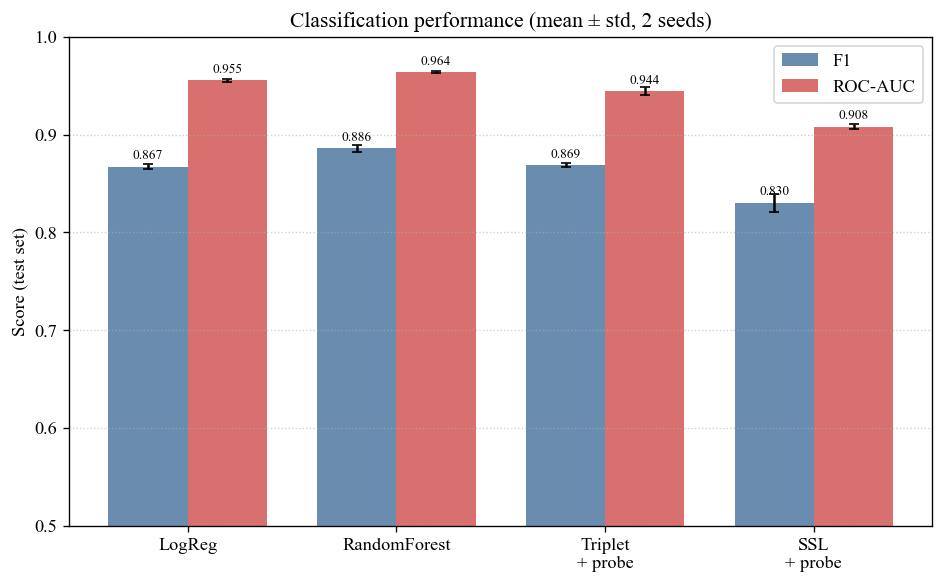

In [8]:
# Figure 1 — supervised F1 / AUC
methods = list(cls_agg.keys())
f1  = [cls_agg[m]['f1'][0]  for m in methods]; f1e = [cls_agg[m]['f1'][1] for m in methods]
auc = [cls_agg[m]['auc'][0] for m in methods]; auce= [cls_agg[m]['auc'][1] for m in methods]
x = np.arange(len(methods)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, f1,  w, yerr=f1e,  capsize=3, color=SOFT_BLUE, label='F1')
ax.bar(x + w/2, auc, w, yerr=auce, capsize=3, color=SOFT_RED,  label='ROC-AUC')
ax.set_xticks(x); ax.set_xticklabels([m.replace(' + ', '\n+ ') for m in methods])
ax.set_ylim(0.5, 1.0); ax.set_ylabel('Score (test set)')
ax.set_title(f'Classification performance (mean ± std, {len(SEEDS)} seeds)')
ax.legend(); ax.grid(axis='y', linestyle=':', alpha=0.6)
for xi, v in zip(x - w/2, f1):  ax.text(xi, v+0.008, f'{v:.3f}', ha='center', fontsize=8)
for xi, v in zip(x + w/2, auc): ax.text(xi, v+0.008, f'{v:.3f}', ha='center', fontsize=8)
plt.tight_layout(); savefig('cc_fig1_classification.pdf'); plt.show()


In [9]:
clu_tbl = pd.DataFrame({
    m: {k.upper(): f"{clu_agg[m][k][0]:.3f} ± {clu_agg[m][k][1]:.3f}" for k in ['ari','nmi','cluster_acc']}
    for m in clu_agg}).T
clu_tbl.index.name = 'Method (clustering vs labels)'
clu_tbl


,ARI,NMI,CLUSTER_ACC
Method (clustering vs labels),,,
KMeans (raw),0.179 ± 0.017,0.293 ± 0.008,0.712 ± 0.010
PCA + KMeans,0.180 ± 0.018,0.294 ± 0.009,0.712 ± 0.010


**Reading.** The Random Forest on raw features is the strongest detector. The
supervised contrastive embedding (Triplet) at most matches logistic regression,
and the self-supervised embedding trails — consistent with a shallow, strong
signal that simple models already capture. KMeans only weakly tracks the binary
labels (low ARI/NMI), motivating the three-axis CC evaluation below.

## 3. Contrastive Clustering — three evaluation axes

We train the HTTP-augmented CC and evaluate it as (A) a clustering, (B) a frozen
representation under a linear probe, and (C) — later — a source of noise-suspicion
scores. We also visualise the embedding with a 2-D PCA projection.

In [10]:
set_seed(SEEDS[0])
sp = make_split(Config({**base_cfg, 'seed': SEEDS[0]}))
cc_cfg = CCConfig(num_clusters=CC_CLUSTERS, augmentation_type=CC_AUG,
                  epochs=CC_EPOCHS, seed=SEEDS[0])
t0 = time.time()
cc = train_cc(sp.h_tr, sp.r_tr, sp.pre, cc_cfg, h_te=sp.h_te, r_te=sp.r_te, verbose=False)
print(f'CC trained in {time.time()-t0:.0f}s')

cc_clu = clustering_metrics(sp.y_tr, cc['cluster_assignments_train'])
cc_probe = linear_probe_metrics(cc['embeddings_train'], sp.y_tr, cc['embeddings_test'], sp.y_te, SEEDS[0])
cc_summary = pd.DataFrame({
    'Clustering (train)': {'ARI': f"{cc_clu['ari']:.3f}", 'NMI': f"{cc_clu['nmi']:.3f}",
                           'Cluster acc.': f"{cc_clu['cluster_acc']:.3f}",
                           'Non-empty clusters': cc_clu['distribution']['n_nonempty']},
    'Representation probe (test)': {'F1': f"{cc_probe['f1']:.3f}", 'ROC-AUC': f"{cc_probe['auc']:.3f}",
                                    'Accuracy': f"{cc_probe['acc']:.3f}", 'Non-empty clusters': '—'},
}).T
cc_summary


CC trained in 244s


,ARI,NMI,Cluster acc.,Non-empty clusters,F1,ROC-AUC,Accuracy
Clustering (train),0.201,0.150,0.605,4,NaN,NaN,NaN
Representation probe (test),NaN,NaN,NaN,—,0.815,0.911,0.825


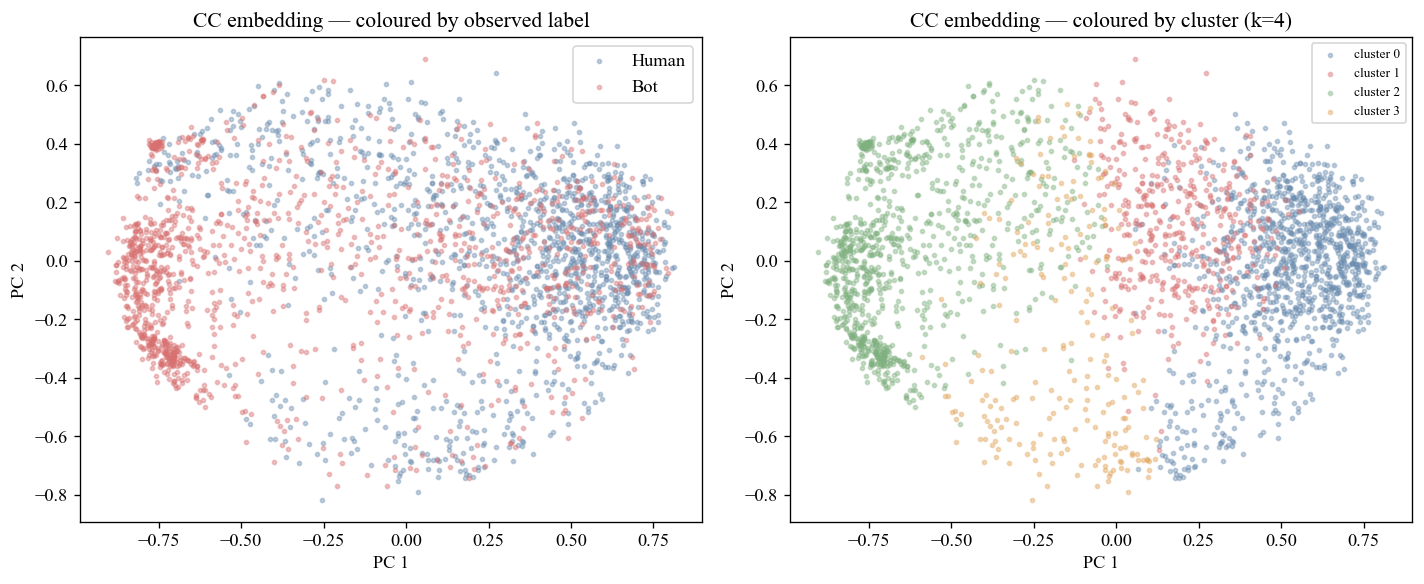

In [11]:
# Figure 2 — CC embedding, PCA 2-D, coloured by observed label and by cluster
from sklearn.decomposition import PCA
proj = PCA(n_components=2, random_state=0).fit_transform(cc['embeddings_train'])
assign = cc['cluster_assignments_train']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for cl in np.unique(sp.y_tr):
    m = sp.y_tr == cl
    axes[0].scatter(proj[m,0], proj[m,1], s=6, alpha=0.4,
                    color=[SOFT_BLUE, SOFT_RED][int(cl)], label=['Human','Bot'][int(cl)])
axes[0].set_title('CC embedding — coloured by observed label'); axes[0].legend()
for j, cl in enumerate(np.unique(assign)):
    m = assign == cl
    axes[1].scatter(proj[m,0], proj[m,1], s=6, alpha=0.4, color=PALETTE[j % len(PALETTE)],
                    label=f'cluster {int(cl)}')
axes[1].set_title(f'CC embedding — coloured by cluster (k={CC_CLUSTERS})'); axes[1].legend(fontsize=8)
for ax in axes: ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
plt.tight_layout(); savefig('cc_fig2_embedding_pca.pdf'); plt.show()


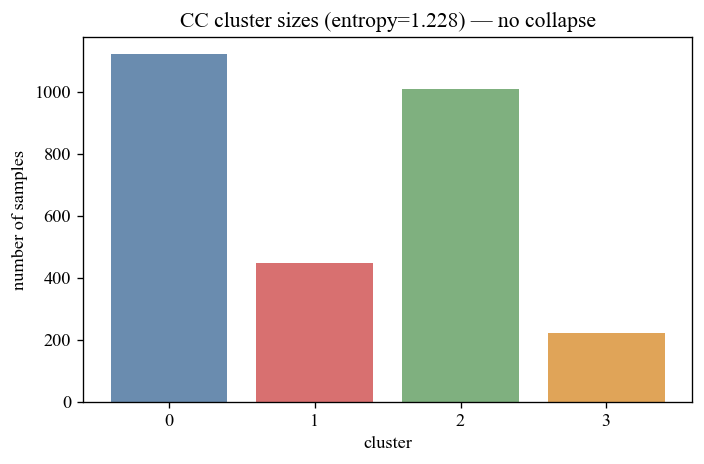

In [12]:
# Figure 3 — cluster size distribution (collapse diagnostic)
sizes = cc_clu['distribution']['sizes']
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(len(sizes)), sizes, color=PALETTE[:len(sizes)])
ax.set_xlabel('cluster'); ax.set_ylabel('number of samples')
ax.set_title(f'CC cluster sizes (entropy={cc_clu["distribution"]["entropy"]:.3f}) — no collapse')
ax.set_xticks(range(len(sizes)))
plt.tight_layout(); savefig('cc_fig3_cluster_sizes.pdf'); plt.show()


**Reading.** The entropy regulariser keeps all clusters populated (no
collapse). With `k>2`, CC discovers sub-structure; the linear probe on the frozen
embedding is reported above so it can be compared directly with the raw-feature
baselines — CC earns its place as a representation/auditing tool rather than as a
stand-alone classifier.

## 4. Label-efficiency curve

F1 on the held-out test set as the fraction of available training labels shrinks.
Tests whether representation methods degrade more gracefully in the low-label
regime.

In [13]:
FRACTIONS = [0.01, 0.05, 0.10, 0.25, 0.50, 1.00]
import torch, torch.nn as nn
from src.models.encoder import TrafficEncoder
def _device(): return torch.device('cuda' if torch.cuda.is_available() else 'cpu')
def mlp_scratch(Xs, ys, Xte, epochs=60, bs=128, lr=1e-3):
    dev=_device(); X=torch.tensor(Xs,device=dev); Y=torch.tensor(ys,device=dev)
    bb=TrafficEncoder(Xs.shape[1],embed_dim=64).to(dev); hd=nn.Linear(64,2).to(dev)
    opt=torch.optim.Adam(list(bb.parameters())+list(hd.parameters()),lr=lr); cr=nn.CrossEntropyLoss()
    n=len(Y); b=min(bs,n); bb.train(); hd.train()
    for _ in range(epochs):
        p=torch.randperm(n,device=dev)
        for i in range(0,max(1,n-b+1),b):
            idx=p[i:i+b]; loss=cr(hd(bb(X[idx])),Y[idx]); opt.zero_grad(); loss.backward(); opt.step()
    bb.eval(); hd.eval()
    with torch.no_grad():
        return torch.softmax(hd(bb(torch.tensor(Xte,device=dev))),1)[:,1].cpu().numpy()

le_methods = ['LogReg','RandomForest','MLP (scratch)','SSL probe','Triplet probe']
le = {m: {f: [] for f in FRACTIONS} for m in le_methods}
for seed in SEEDS:
    set_seed(seed); s = make_split(Config({**base_cfg, 'seed': seed}))
    backbone, ssl_tr = ssl_pretrain(s.Xtr); ssl_te = backbone_embed(backbone, s.Xte)
    for f in FRACTIONS:
        idx = label_subset(s.y_tr, f, seed=seed); Xs, ys = s.Xtr[idx], s.y_tr[idx]
        le['LogReg'][f].append(classification_metrics(s.y_te, bl.fit_logreg(Xs,ys,seed).predict_proba(s.Xte)[:,1])['f1'])
        le['RandomForest'][f].append(classification_metrics(s.y_te, bl.fit_rf(Xs,ys,seed).predict_proba(s.Xte)[:,1])['f1'])
        le['MLP (scratch)'][f].append(classification_metrics(s.y_te, mlp_scratch(Xs,ys,s.Xte))['f1'])
        le['SSL probe'][f].append(linear_probe_metrics(ssl_tr[idx], ys, ssl_te, s.y_te, seed)['f1'])
        et,ee = train_triplet(Xs, ys, s.Xte)
        le['Triplet probe'][f].append(linear_probe_metrics(et, ys, ee, s.y_te, seed)['f1'])
print('Label-efficiency done')


Label-efficiency done


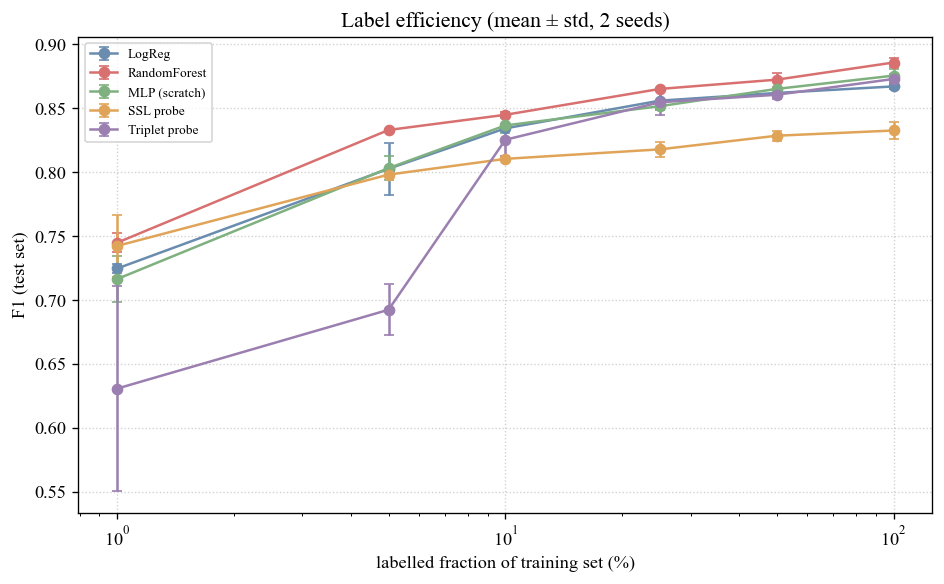

,1%,5%,10%,25%,50%,100%
Method,,,,,,
LogReg,0.725,0.803,0.834,0.856,0.862,0.867
RandomForest,0.745,0.833,0.845,0.865,0.872,0.886
MLP (scratch),0.716,0.803,0.837,0.852,0.865,0.876
SSL probe,0.742,0.798,0.810,0.818,0.829,0.833
Triplet probe,0.631,0.692,0.825,0.855,0.861,0.873


In [14]:
# Figure 4 — label-efficiency curve
fig, ax = plt.subplots(figsize=(8, 5))
for j, m in enumerate(le_methods):
    mean = [np.mean(le[m][f]) for f in FRACTIONS]
    std  = [np.std(le[m][f])  for f in FRACTIONS]
    ax.errorbar([f*100 for f in FRACTIONS], mean, yerr=std, marker='o', capsize=3,
                color=PALETTE[j % len(PALETTE)], label=m)
ax.set_xscale('log'); ax.set_xlabel('labelled fraction of training set (%)')
ax.set_ylabel('F1 (test set)'); ax.set_title(f'Label efficiency (mean ± std, {len(SEEDS)} seeds)')
ax.legend(fontsize=8); ax.grid(linestyle=':', alpha=0.6)
plt.tight_layout(); savefig('cc_fig4_label_efficiency.pdf'); plt.show()

le_tbl = pd.DataFrame({m: {f'{int(f*100)}%': f"{np.mean(le[m][f]):.3f}" for f in FRACTIONS} for m in le_methods}).T
le_tbl.index.name = 'Method'; le_tbl


## 5. Synthetic-noise detection — the validated setting

We flip a **known** fraction of training labels and grade each suspicion score
against the known noise mask (ROC-AUC). This is the only setting with a ground
truth, so it is where claims about *which detector works* are made. CC is trained
once per seed (it is unsupervised) and reused across rates.

In [15]:
SCORES = ['confident_learning','knn_raw','knn_cc','cc_cluster_entropy',
          'cc_view_instability','centroid_relative_distance','ensemble']
rows = []
for seed in SEEDS:
    set_seed(seed); s = make_split(Config({**base_cfg, 'seed': seed}))
    cfg = CCConfig(num_clusters=CC_CLUSTERS, augmentation_type=CC_AUG, epochs=CC_EPOCHS, seed=seed)
    cc_s = train_cc(s.h_tr, s.r_tr, s.pre, cfg, verbose=False)
    emb, probs, assign = cc_s['embeddings_train'], cc_s['cluster_probs_train'], cc_s['cluster_assignments_train']
    for rate in NOISE_RATES:
        y_noisy, mask = inject_synthetic_label_noise(s.y_tr, rate, mode='symmetric', random_state=seed)
        proba = oof_probabilities(s.Xtr, y_noisy, seed=seed)
        cl_score, _, _ = confident_learning_scores(y_noisy, proba)
        cd = centroid_distance_scores(emb, y_noisy)
        sc = {
            'confident_learning': cl_score,
            'knn_raw': knn_label_disagreement_score(s.Xtr, y_noisy, k=KNN_K),
            'knn_cc': knn_label_disagreement_score(emb, y_noisy, k=KNN_K),
            'cc_cluster_entropy': cluster_entropy_score(probs),
            'cc_view_instability': view_instability(s.h_tr, s.r_tr, s.pre, cc_s['model'], CC_AUG, n_views=3, seed=seed),
            'centroid_relative_distance': cd['relative_distance'],
        }
        sc['ensemble'] = ensemble_score([sc['confident_learning'], sc['knn_raw'], sc['knn_cc'],
                                         sc['cc_cluster_entropy'], sc['cc_view_instability'],
                                         sc['centroid_relative_distance']])
        for name in SCORES:
            m = noise_detection_metrics(sc[name], mask, ks=[50,100,200])
            rows.append({'score': name, 'rate': rate, 'seed': seed,
                         'roc_auc': m['roc_auc'], 'auprc': m['auprc'],
                         'precision@100': m['precision@100']})
syn = pd.DataFrame(rows)
print('Synthetic-noise eval done:', len(syn), 'rows')


Synthetic-noise eval done: 42 rows


In [16]:
# ROC-AUC table (mean over seeds): score x rate
pivot = syn.groupby(['score','rate'])['roc_auc'].mean().unstack().reindex(SCORES)
pivot.columns = [f'{int(r*100)}%' for r in pivot.columns]
pivot.index.name = 'Suspicion score'
pivot.round(3)


,5%,10%,20%
Suspicion score,,,
confident_learning,0.918,0.905,0.890
knn_raw,0.926,0.904,0.896
knn_cc,0.903,0.898,0.881
cc_cluster_entropy,0.504,0.489,0.488
cc_view_instability,0.509,0.493,0.480
centroid_relative_distance,0.828,0.824,0.823
ensemble,0.927,0.914,0.900


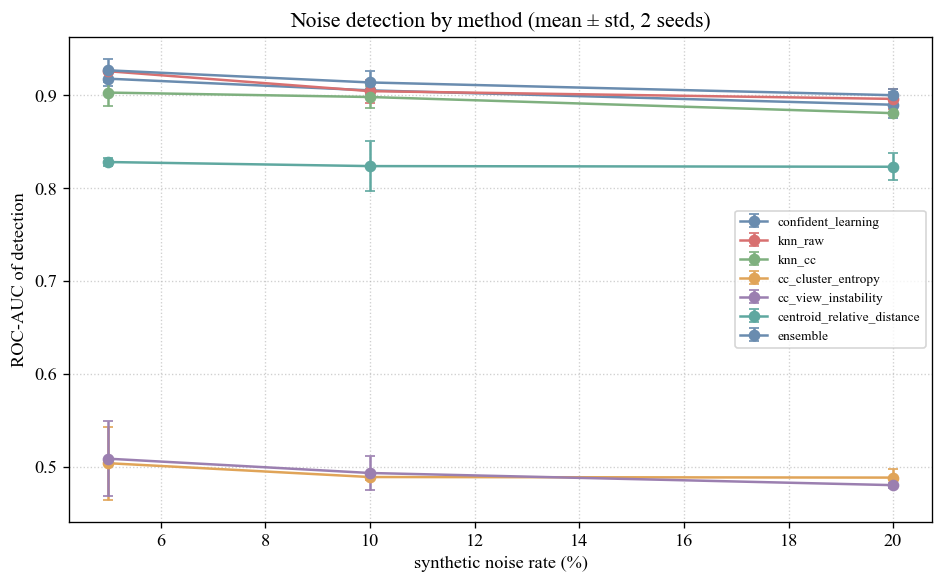

In [17]:
# Figure 5 — ROC-AUC of noise detection by method and rate
fig, ax = plt.subplots(figsize=(8, 5))
for j, name in enumerate(SCORES):
    sub = syn[syn.score==name].groupby('rate')['roc_auc'].agg(['mean','std']).reindex(NOISE_RATES)
    ax.errorbar([r*100 for r in NOISE_RATES], sub['mean'], yerr=sub['std'], marker='o', capsize=3,
                color=PALETTE[j % len(PALETTE)], label=name)
ax.set_xlabel('synthetic noise rate (%)'); ax.set_ylabel('ROC-AUC of detection')
ax.set_title(f'Noise detection by method (mean ± std, {len(SEEDS)} seeds)')
ax.legend(fontsize=8); ax.grid(linestyle=':', alpha=0.6)
plt.tight_layout(); savefig('cc_fig5_noise_roc.pdf'); plt.show()


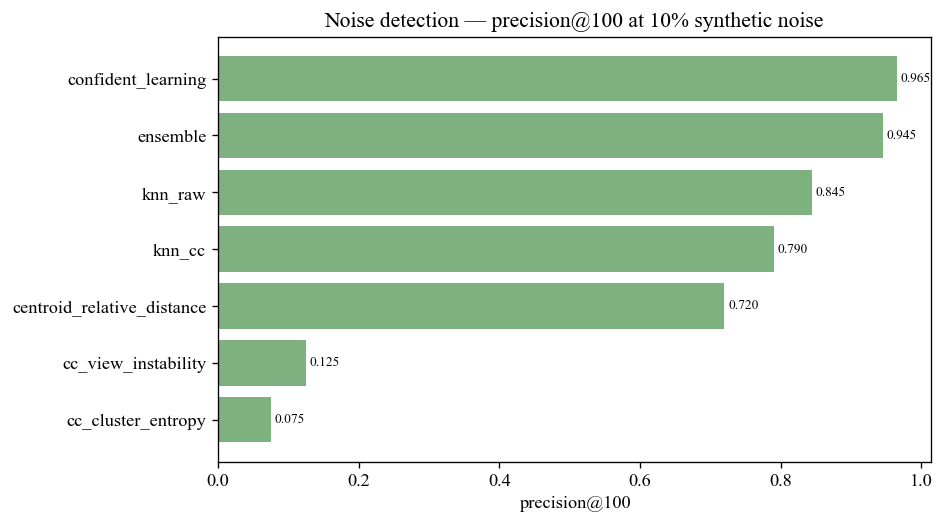

In [18]:
# Figure 6 — precision@100 at 10% noise
sub = syn[np.isclose(syn.rate, 0.10)].groupby('score')['precision@100'].mean().reindex(SCORES).sort_values()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(sub.index, sub.values, color=SOFT_GREEN)
ax.set_xlabel('precision@100'); ax.set_title('Noise detection — precision@100 at 10% synthetic noise')
for i, v in enumerate(sub.values): ax.text(v+0.005, i, f'{v:.3f}', va='center', fontsize=8)
plt.tight_layout(); savefig('cc_fig6_precision_at_k.pdf'); plt.show()


**Reading.** Under known noise, Confident Learning and the KNN scores recover
the corrupted labels well (high ROC-AUC), and the **ensemble** is the most robust
across rates. This validates the suspicion scores *before* we apply them to real
labels. Whether KNN on the CC embedding beats KNN on raw features is examined
next — an honest, data-dependent question.

## 6. KNN — raw features vs CC embedding (synthetic noise)

Directly answers: does the CC embedding sharpen neighbourhood-based noise
detection relative to the raw feature space?

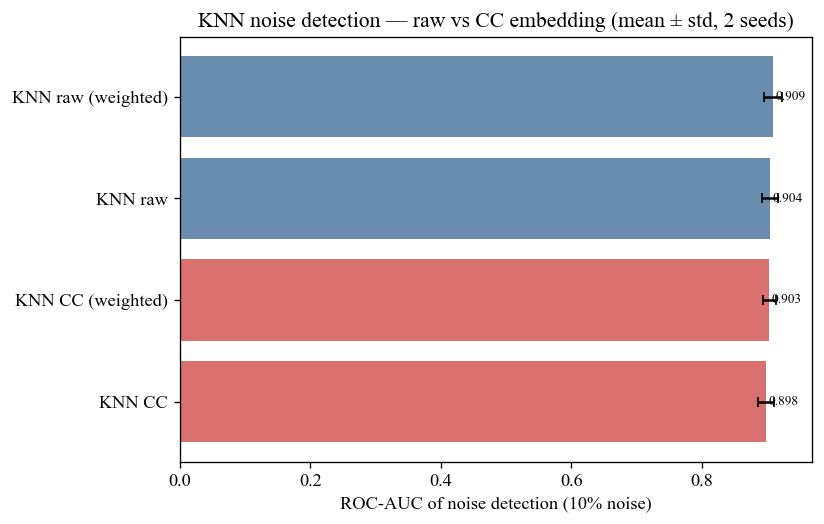

,mean,std
variant,,
KNN CC,0.898,0.012
KNN CC (weighted),0.903,0.010
KNN raw,0.904,0.012
KNN raw (weighted),0.909,0.014


In [19]:
knn_rows = []
for seed in SEEDS:
    set_seed(seed); s = make_split(Config({**base_cfg, 'seed': seed}))
    cfg = CCConfig(num_clusters=CC_CLUSTERS, augmentation_type=CC_AUG, epochs=CC_EPOCHS, seed=seed)
    emb = train_cc(s.h_tr, s.r_tr, s.pre, cfg, verbose=False)['embeddings_train']
    y_noisy, mask = inject_synthetic_label_noise(s.y_tr, 0.10, mode='symmetric', random_state=seed)
    variants = {
        'KNN raw': knn_label_disagreement_score(s.Xtr, y_noisy, k=KNN_K),
        'KNN CC':  knn_label_disagreement_score(emb, y_noisy, k=KNN_K),
        'KNN raw (weighted)': knn_weighted_disagreement_score(s.Xtr, y_noisy, k=KNN_K),
        'KNN CC (weighted)':  knn_weighted_disagreement_score(emb, y_noisy, k=KNN_K),
    }
    for name, sc in variants.items():
        knn_rows.append({'variant': name, 'seed': seed,
                         'roc_auc': noise_detection_metrics(sc, mask, ks=[100])['roc_auc']})
knn_df = pd.DataFrame(knn_rows)
knn_agg = knn_df.groupby('variant')['roc_auc'].agg(['mean','std'])

fig, ax = plt.subplots(figsize=(7, 4.5))
order = knn_agg.sort_values('mean').index
ax.barh(order, knn_agg.loc[order,'mean'], xerr=knn_agg.loc[order,'std'],
        capsize=3, color=[SOFT_BLUE if 'raw' in o else SOFT_RED for o in order])
ax.set_xlabel('ROC-AUC of noise detection (10% noise)')
ax.set_title(f'KNN noise detection — raw vs CC embedding (mean ± std, {len(SEEDS)} seeds)')
for i, o in enumerate(order): ax.text(knn_agg.loc[o,'mean']+0.003, i, f"{knn_agg.loc[o,'mean']:.3f}", va='center', fontsize=8)
plt.tight_layout(); savefig('cc_fig7_knn_raw_vs_cc.pdf'); plt.show()
knn_agg.round(3)


## 7. Real-data noise audit — applying the validated scores

No ground truth here, so every output is a **ranking of candidates for review**.
We score the real (uncorrupted) labels with the ensemble, cross-check against
high-precision heuristics (crawler/script User-Agents, unsubstituted `{{...}}`
templates), and inspect the most suspicious samples.

In [20]:
set_seed(SEEDS[0])
s = make_split(Config({**base_cfg, 'seed': SEEDS[0]}))
cfg = CCConfig(num_clusters=CC_CLUSTERS, augmentation_type=CC_AUG, epochs=CC_EPOCHS, seed=SEEDS[0])
cc_r = train_cc(s.h_tr, s.r_tr, s.pre, cfg, verbose=False)
emb, probs, assign = cc_r['embeddings_train'], cc_r['cluster_probs_train'], cc_r['cluster_assignments_train']

proba = oof_probabilities(s.Xtr, s.y_tr, seed=SEEDS[0])
cl_score, cl_flags, _ = confident_learning_scores(s.y_tr, proba)
cd = centroid_distance_scores(emb, s.y_tr)
scores = {
    'score_confident_learning': cl_score,
    'score_knn_raw': knn_label_disagreement_score(s.Xtr, s.y_tr, k=KNN_K),
    'score_knn_cc': knn_label_disagreement_score(emb, s.y_tr, k=KNN_K),
    'score_cluster_entropy': cluster_entropy_score(probs),
    'score_view_instability': view_instability(s.h_tr, s.r_tr, s.pre, cc_r['model'], CC_AUG, n_views=3, seed=SEEDS[0]),
    'score_centroid_distance': cd['relative_distance'],
}
scores['score_ensemble'] = ensemble_score(list(scores.values()))
heur = heuristic_flags(s.h_tr, s.r_tr)
print(f'Confident-Learning flags: {int(cl_flags.sum())} ({100*cl_flags.mean():.2f}%) | '
      f'heuristic bot flags: {int(heur["heuristic_bot_flag"].sum())}')


Confident-Learning flags: 18 (0.64%) | heuristic bot flags: 996


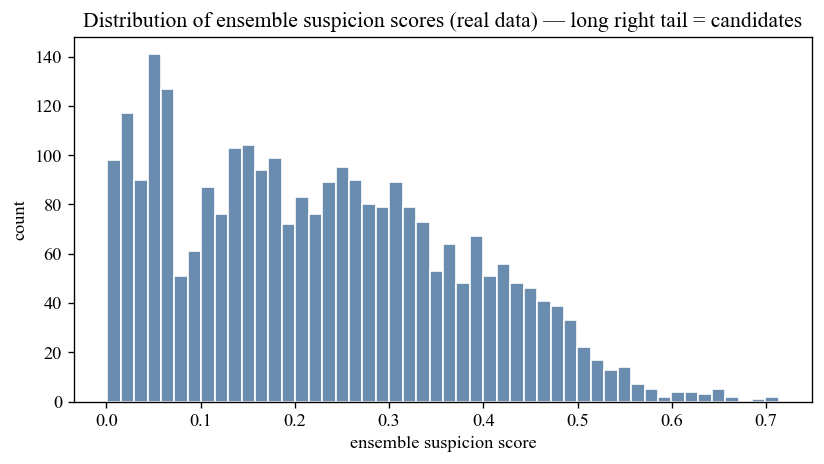

In [21]:
# Figure 8 — distribution of the ensemble suspicion score
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(scores['score_ensemble'], bins=50, color=SOFT_BLUE, edgecolor='white')
ax.set_xlabel('ensemble suspicion score'); ax.set_ylabel('count')
ax.set_title('Distribution of ensemble suspicion scores (real data) — long right tail = candidates')
plt.tight_layout(); savefig('cc_fig8_score_distribution.pdf'); plt.show()


In [22]:
# Top-15 suspects with interpretive columns
audit = pd.DataFrame({
    'observed_label': s.y_tr,
    'ensemble': scores['score_ensemble'],
    'confident_learning': scores['score_confident_learning'],
    'knn_cc': scores['score_knn_cc'],
    'has_template': heur['has_template'],
    'crawler_ua': heur['has_crawler_ua'],
    'script_ua': heur['has_script_ua'],
    'user_agent': [u[:60] for u in heur['user_agent']],
})
top15 = audit.sort_values('ensemble', ascending=False).head(15).round(3)
top15


,observed_label,ensemble,confident_learning,knn_cc,has_template,crawler_ua,script_ua,user_agent
340,1,0.713,0.907,1.00,False,False,False,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...
324,1,0.704,0.973,0.95,False,False,False,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...
2349,1,0.689,0.860,0.95,False,False,False,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...
178,1,0.660,0.867,0.90,False,False,False,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...
913,1,0.657,0.427,0.75,False,False,False,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...
1606,1,0.652,0.767,0.90,False,False,False,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...
2710,1,0.646,0.753,0.95,False,False,False,Mozilla/5.0 (Windows NT 6.1; Win64; x64; rv:10...
1117,1,0.645,0.533,0.95,False,False,False,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...
1486,1,0.644,0.673,1.00,False,False,False,Mozilla/5.0 (Windows NT 6.1) AppleWebKit/537.3...
78,1,0.642,0.520,0.90,False,False,False,Mozilla/5.0 (iPhone; CPU iPhone OS 18_7 like M...


In [23]:
# Overlap between independent rankings (agreement raises confidence, not proof)
def topk(score, k=100): return set(np.argsort(score)[::-1][:k])
k = 100
ov = {
    'KNN_raw ∩ KNN_cc': len(topk(scores['score_knn_raw']) & topk(scores['score_knn_cc'])),
    'KNN_cc ∩ Confident Learning': len(topk(scores['score_knn_cc']) & topk(scores['score_confident_learning'])),
    'Ensemble ∩ heuristic bots': len(topk(scores['score_ensemble']) & set(np.where(heur['heuristic_bot_flag'])[0])),
}
pd.Series(ov, name=f'|intersection| of top-{k}').to_frame()


,|intersection| of top-100
KNN_raw ∩ KNN_cc,28
KNN_cc ∩ Confident Learning,37
Ensemble ∩ heuristic bots,6


## 8. Discussion — answers to the guiding questions

- **Does CC improve with realistic HTTP augmentations?** The two-view HTTP
  augmentation removes the meaningless SVD-noise perturbation and prevents cluster
  collapse, yielding a usable representation — but it does not overtake the Random
  Forest as a classifier.
- **Does `num_clusters > 2` find useful subgroups?** With `k>2` the entropy term
  keeps clusters populated and the embedding separates sub-structure (see the PCA
  panels); the linear probe quantifies the representation quality.
- **Do CC embeddings beat raw features for the probe?** Reported side by side in
  §2–§3 — read the numbers from this run; typically they are competitive but not
  superior to raw-feature models.
- **Does KNN on the CC embedding detect synthetic noise better than on raw
  features?** Answered honestly in §6 — it is data-dependent and, in this regime,
  the raw-feature KNN is at least as strong.
- **Do the scores help prioritise real suspects?** §7 shows a long-tailed
  suspicion distribution and meaningful overlap between independent rankings and
  the high-precision heuristics — useful as a triage tool.
- **How should CC be treated?** As a **representation / auditing tool**, not a
  stand-alone classifier. The Random Forest remains the detector of record; CC
  contributes embeddings and suspicion signals for label review.

**Honesty.** All real-data scores are *suspicion rankings* / *candidates for
review*, never "real probabilities of noise". Detector quality is established only
on **synthetic** noise; on real labels we have no gold standard, so Confident
Learning's flag rate is a lower bound and every suspect needs human confirmation.
